# Notebook 3: DEM Differencing and Uncertainty Propagation

This notebook follows the xDEM documentation workflow (Hugonnet et al. 2022) exactly:

1. Load co-registered DEMs and glacier outlines
2. Compute dh (elevation difference) rasters
3. Estimate heteroscedastic measurement error from stable terrain as a function of slope and curvature
4. Standardize dh by the measurement error
5. Fit a variogram to the standardized dh on stable terrain
6. Compute effective number of samples per glacier polygon
7. Destandardize to get final uncertainty on mean elevation change per glacier
8. Compute volume change and report results

**Reviewer note:** This replaces the original approach of converting off-glacier NMAD directly
to m w.e. uncertainty, which incorrectly ignores spatial autocorrelation of elevation errors.
The correct approach (Hugonnet et al. 2022, Rolstad et al. 2009) propagates pixel-level
uncertainty through spatial aggregation accounting for the correlation length of errors.

**Inputs** (from Notebooks 1 and 2):
- `coreg_dems/<name>_coreg.tif`
- Glacier shapefiles (DGA 2000 and 2019)
- `coreg_dems/glacier_union_mask.shp`

**Outputs**:
- `differenced_dems/<epoch>_dh.tif`
- `results/glacier_results.csv`
- `figures/`

In [1]:
# Step 1: Imports and user variables

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from geoutils.stats import nmad
import geoutils as gu
import xdem

print(f'xDEM version: {xdem.__version__}')

# --- USER VARIABLES ---
coreg_folder = 'coreg_dems_xdem'
output_folder = 'differenced_dems'
results_folder = 'results'
figures_folder = 'figures'
for d in [output_folder, results_folder, figures_folder]:
    os.makedirs(d, exist_ok=True)

glacier_2000_path = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp'
glacier_2019_path = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp'
glacier_union_path = os.path.join(coreg_folder, 'glacier_union_mask.shp')

# Ice density for volume to mass conversion (Huss 2013)
ICE_DENSITY   = 850.0   # kg m-3
WATER_DENSITY = 1000.0  # kg m-3
DENSITY_FACTOR = ICE_DENSITY / WATER_DENSITY  # 0.85

# Glacier ID field in shapefiles
GLACIER_ID_FIELD = 'COD_GLA'

# Differencing epochs: (current, baseline, outline_year, t_start, t_end)
# outline_year: '2000', '2019', or 'union'
# For epochs involving the 1954 DEM we use 'union' of outlines as the
# glacier mask — per reviewer comment, 2000 outlines include terrain
# that was ice in 1954, so the union is more conservative.
EPOCHS = [
    ('CerroBlanco_2024', 'IGM_1954',  'union', 1954, 2024),
    ('LasTermas_2024',   'IGM_1954',  'union', 1954, 2024),
    ('CerroBlanco_2024', 'SRTM_2000', '2019',  2000, 2024),
    ('LasTermas_2024',   'SRTM_2000', '2019',  2000, 2024),
    ('SRTM_2000',        'IGM_1954',  'union', 1954, 2000),
]

xDEM version: 0.2.2


In [2]:
# Step 2: Load glacier outlines and create masks

gdf_2000 = gpd.read_file(glacier_2000_path)
gdf_2019 = gpd.read_file(glacier_2019_path)
gdf_union = gpd.read_file(glacier_union_path)

print(f'DGA 2000: {len(gdf_2000)} polygons, CRS: {gdf_2000.crs}')
print(f'DGA 2019: {len(gdf_2019)} polygons, CRS: {gdf_2019.crs}')
print(f'Union:    {len(gdf_union)} polygon(s)')

def load_outlines(label, target_crs):
    """Load glacier outlines for a given epoch label."""
    if label == '2000':
        gdf = gpd.read_file(glacier_2000_path)
    elif label == '2019':
        gdf = gpd.read_file(glacier_2019_path)
    elif label == 'union':
        gdf = gpd.read_file(glacier_union_path)
        gdf[GLACIER_ID_FIELD] = 'UNION'
    else:
        raise ValueError(f'Unknown outline label: {label}')
    
    # Drop null geometries and empty geometries
    gdf = gdf[~gdf.geometry.isna()]
    gdf = gdf[~gdf.geometry.is_empty]
    gdf = gdf.reset_index(drop=True)
    
    return gdf.to_crs(target_crs)

DGA 2000: 28 polygons, CRS: EPSG:32719
DGA 2019: 993 polygons, CRS: EPSG:32719
Union:    1 polygon(s)


In [3]:
# Step 3: Load reference DEM and compute terrain attributes
# Following xDEM docs exactly: slope and max curvature are computed
# from the reference DEM and used to model heteroscedastic elevation error.

srtm_path = os.path.join(coreg_folder, 'SRTM_2000_coreg.tif')
if not os.path.exists(srtm_path):
    srtm_path = 'aligned_dems/SRTM_2000_aligned.tif'

print(f'Loading reference DEM: {srtm_path}')
ref_dem = xdem.DEM(srtm_path)
print(f'  CRS: {ref_dem.crs}  |  Resolution: {ref_dem.res}')

# Compute slope, planform curvature, profile curvature
# (following xDEM standardization example exactly)
print('\nComputing terrain attributes...')
slope, planc, profc = xdem.terrain.get_terrain_attribute(
    dem=ref_dem,
    attribute=['slope', 'planform_curvature', 'profile_curvature']
)
# Max curvature = maximum of absolute planform and profile curvature
maxc = np.maximum(np.abs(profc), np.abs(planc))
print('  Slope and curvature computed.')

# Create glacier union mask on reference DEM grid
glacier_vec  = gu.Vector(glacier_union_path)
mask_glacier = glacier_vec.create_mask(ref_dem)  # True = glacier
print(f'  Glacier mask: {int(np.sum(np.array(mask_glacier.data).squeeze())):,} glacier pixels')

Loading reference DEM: aligned_dems/SRTM_2000_aligned.tif
  CRS: EPSG:32719  |  Resolution: (30.0, 30.0)

Computing terrain attributes...
  Slope and curvature computed.
  Glacier mask: 3,693 glacier pixels


In [4]:
# Step 4: For each epoch, compute dh and run the full uncertainty pipeline
# Following the xDEM standardization + variogram workflow from the docs.

all_results = []

for current_name, baseline_name, outline_label, t_start, t_end in EPOCHS:
    dt = t_end - t_start
    epoch_label = f'{current_name}_minus_{baseline_name}'
    print(f'\n{"="*60}')
    print(f'Epoch: {epoch_label}  ({t_start}-{t_end}, dt={dt} yr)')
    print(f'{"="*60}')

    # Load DEMs
    curr_path = os.path.join(coreg_folder, f'{current_name}_coreg.tif')
    base_path = os.path.join(coreg_folder, f'{baseline_name}_coreg.tif')
    if not os.path.exists(curr_path):
        curr_path = f'aligned_dems/{current_name}_aligned.tif'
    if not os.path.exists(base_path):
        base_path = f'aligned_dems/{baseline_name}_aligned.tif'

    dem_current  = xdem.DEM(curr_path)
    dem_baseline = xdem.DEM(base_path)

    # Compute elevation difference: current - baseline
    dh = dem_current - dem_baseline

    # Save dh raster
    dh_path = os.path.join(output_folder, f'{epoch_label}_dh.tif')
    dh.to_file(dh_path)
    print(f'  dh raster saved: {dh_path}')

    # ----------------------------------------------------------------
    # UNCERTAINTY STEP 1: Estimate heteroscedastic measurement error
    # from stable terrain as a function of slope and max curvature.
    # Following xDEM docs: Hugonnet et al. (2022)
    # ----------------------------------------------------------------

    # Extract stable terrain values (not glacier)
    dh_arr    = dh[~mask_glacier].filled(np.nan)
    slope_arr = slope[~mask_glacier].filled(np.nan)
    planc_arr = planc[~mask_glacier].filled(np.nan)
    profc_arr = profc[~mask_glacier].filled(np.nan)
    maxc_arr  = np.maximum(np.abs(planc_arr), np.abs(profc_arr))

    # Remove large outliers (4*NMAD threshold)
    nmad_stable = nmad(dh_arr[np.isfinite(dh_arr)])
    dh_arr[np.abs(dh_arr) > 4 * nmad_stable] = np.nan
    print(f'  Stable terrain NMAD: {nmad_stable:.3f} m')
    print(f'  Stable terrain pixels: {np.sum(np.isfinite(dh_arr)):,}')

    # Define bins for 2D binning (following xDEM docs exactly)
    finite_slope = slope_arr[np.isfinite(slope_arr) & np.isfinite(dh_arr)]
    finite_maxc  = maxc_arr[np.isfinite(maxc_arr)  & np.isfinite(dh_arr)]

    if len(finite_slope) < 50:
        print(f'  WARNING: only {len(finite_slope)} stable pixels — using NMAD directly.')
        dh_err_map  = np.full(np.array(slope.data).squeeze().shape, nmad_stable)
        dh_err_mean = nmad_stable
        scale_fac   = 1.0
        skip_variogram = True
        variogram_ok   = False
        params_vgm     = None
    else:
        skip_variogram = False
        custom_bin_slope = np.unique(np.concatenate([
            np.nanquantile(finite_slope, np.linspace(0, 0.95, 20)),
            np.nanquantile(finite_slope, np.linspace(0.96, 0.99, 5)),
            np.nanquantile(finite_slope, np.linspace(0.991, 1, 10)),
        ]))
        custom_bin_curv = np.unique(np.concatenate([
            np.nanquantile(finite_maxc, np.linspace(0, 0.95, 20)),
            np.nanquantile(finite_maxc, np.linspace(0.96, 0.99, 5)),
            np.nanquantile(finite_maxc, np.linspace(0.991, 1, 10)),
        ]))

        # 2D binning to estimate measurement error
        df_bins = xdem.spatialstats.nd_binning(
            values=dh_arr,
            list_var=[slope_arr, maxc_arr],
            list_var_names=['slope', 'maxc'],
            statistics=['count', np.nanmedian, nmad],
            list_var_bins=[custom_bin_slope, custom_bin_curv],
        )

        # Try 2D interpolation, fall back to 1D (slope only), then constant NMAD
        try:
            slope_curv_to_dh_err = xdem.spatialstats.interp_nd_binning(
                df_bins,
                list_var_names=['slope', 'maxc'],
                statistic='nmad',
                min_count=10,
            )
            dh_err_map = slope_curv_to_dh_err((slope.data, maxc.data))
            print(f'  2D heteroscedastic error map computed.')
        except Exception as e:
            print(f'  WARNING: 2D binning failed ({type(e).__name__}). Trying 1D (slope only)...')
            try:
                df_bins_1d = xdem.spatialstats.nd_binning(
                    values=dh_arr,
                    list_var=[slope_arr],
                    list_var_names=['slope'],
                    statistics=['count', np.nanmedian, nmad],
                    list_var_bins=[custom_bin_slope],
                )
                slope_to_dh_err = xdem.spatialstats.interp_nd_binning(
                    df_bins_1d,
                    list_var_names=['slope'],
                    statistic='nmad',
                    min_count=5,
                )
                dh_err_map = slope_to_dh_err((slope.data,))
                print(f'  1D heteroscedastic error map computed (slope only).')
            except Exception as e2:
                print(f'  WARNING: 1D binning also failed ({type(e2).__name__}). Using constant NMAD.')
                dh_err_map = np.full(np.array(slope.data).squeeze().shape, nmad_stable)

        dh_err_mean = float(np.nanmean(dh_err_map[np.isfinite(dh_err_map)]))
        print(f'  Mean per-pixel measurement error: {dh_err_mean:.3f} m')

        # ----------------------------------------------------------------
        # UNCERTAINTY STEP 2: Standardize dh by measurement error
        # ----------------------------------------------------------------
        z_dh = dh.data / dh_err_map
        z_dh_arr = np.array(z_dh).squeeze().astype(float)
        z_dh_arr[np.array(mask_glacier.data).squeeze()] = np.nan
        z_dh_arr[np.abs(z_dh_arr) > 4] = np.nan

        # Scale correction so spread is exactly 1
        scale_fac = nmad(z_dh_arr[np.isfinite(z_dh_arr)])
        z_dh_arr  = z_dh_arr / scale_fac
        print(f'  Standardized NMAD (should be ~1): {nmad(z_dh_arr[np.isfinite(z_dh_arr)]):.3f}')

        # ----------------------------------------------------------------
        # UNCERTAINTY STEP 3: Fit variogram to standardized stable terrain dh
        # ----------------------------------------------------------------
        print('  Fitting variogram...')
        try:
            df_vgm = xdem.spatialstats.sample_empirical_variogram(
                values=z_dh_arr,
                gsd=ref_dem.res[0],
                subsample=500,
                n_variograms=5,
                estimator='dowd',
                random_state=42,
            )
            func_sum_vgm, params_vgm = xdem.spatialstats.fit_sum_model_variogram(
                ['Gaussian', 'Spherical'],
                empirical_variogram=df_vgm,
            )
            print(f'  Variogram fitted. Parameters: {params_vgm}')

            # Save variogram plot
            fig_vgm, ax_vgm = plt.subplots(figsize=(7, 4))
            xdem.spatialstats.plot_variogram(
                df_vgm,
                xscale_range_split=[100, 1000, 10000],
                list_fit_fun=[func_sum_vgm],
                list_fit_fun_label=['Standardized double-range variogram'],
                ax=ax_vgm,
            )
            ax_vgm.set_title(f'Variogram — {epoch_label}')
            fig_vgm.savefig(os.path.join(figures_folder, f'variogram_{epoch_label}.png'),
                            dpi=150, bbox_inches='tight')
            plt.close(fig_vgm)
            variogram_ok = True
        except Exception as e:
            print(f'  WARNING: Variogram fitting failed ({e}). Using NMAD-only uncertainty.')
            params_vgm   = None
            variogram_ok = False

    # ----------------------------------------------------------------
    # UNCERTAINTY STEP 4: Per-glacier uncertainty via neff
    # ----------------------------------------------------------------
    with rasterio.open(curr_path) as src:
        dem_crs = src.crs
    outlines_gdf = load_outlines(outline_label, dem_crs)

    dh_arr_full = np.array(dh.data).squeeze().astype(float)
    dh_arr_full[dh_arr_full > 1e10] = np.nan
    dh_arr_full[dh_arr_full < -1e4] = np.nan

    for _, row in outlines_gdf.iterrows():
        glacier_id   = row.get(GLACIER_ID_FIELD, 'unknown')
        glacier_area = row.geometry.area

        glacier_single = gu.Vector(gpd.GeoDataFrame([row], crs=outlines_gdf.crs))
        mask_single    = glacier_single.create_mask(ref_dem)
        mask_arr       = np.array(mask_single.data).squeeze()

        dh_glacier = dh_arr_full[mask_arr]
        dh_glacier = dh_glacier[np.isfinite(dh_glacier)]

        if len(dh_glacier) == 0:
            print(f'  {glacier_id}: no valid dh pixels, skipping.')
            continue

        mean_dh    = float(np.nanmean(dh_glacier))
        mean_dh_yr = mean_dh / dt

        if not skip_variogram and variogram_ok:
            neff = xdem.spatialstats.neff_circular_approx_numerical(
                area=glacier_area,
                params_variogram_model=params_vgm,
            )
            z_err          = 1 / np.sqrt(neff)
            dh_err_glacier = float(np.nanmean(dh_err_map[mask_arr]))
            sigma_dh       = scale_fac * dh_err_glacier * z_err
        else:
            n_pixels = len(dh_glacier)
            sigma_dh = nmad_stable / np.sqrt(n_pixels)
            neff     = float(n_pixels)

        sigma_dh_yr = sigma_dh / dt
        sigma_dV    = sigma_dh * glacier_area
        sigma_mb    = sigma_dh_yr * DENSITY_FACTOR
        dV          = mean_dh * glacier_area
        dV_yr       = dV / dt
        mb_yr       = mean_dh_yr * DENSITY_FACTOR

        print(f'  {glacier_id}: dh={mean_dh:.2f}m, dh/yr={mean_dh_yr:.3f}m/yr, '
              f'sigma_dh={sigma_dh:.3f}m, neff={neff:.1f}')

        all_results.append({
            'glacier_id':      glacier_id,
            'epoch':           epoch_label,
            't_start':         t_start,
            't_end':           t_end,
            'dt_yr':           dt,
            'outline_set':     outline_label,
            'area_m2':         round(glacier_area, 2),
            'n_pixels':        len(dh_glacier),
            'n_eff':           round(neff, 2),
            'mean_dh_m':       round(mean_dh, 4),
            'mean_dh_yr_m':    round(mean_dh_yr, 4),
            'dV_m3':           round(dV, 2),
            'dV_yr_m3':        round(dV_yr, 2),
            'mb_mwe_yr':       round(mb_yr, 4),
            'sigma_dh_m':      round(sigma_dh, 4),
            'sigma_dh_yr_m':   round(sigma_dh_yr, 4),
            'sigma_dV_m3':     round(sigma_dV, 2),
            'sigma_mb_mwe_yr': round(sigma_mb, 4),
            'nmad_stable_m':   round(nmad_stable, 4),
        })

# Save results
results_df   = pd.DataFrame(all_results)
results_path = os.path.join(results_folder, 'glacier_results.csv')
results_df.to_csv(results_path, index=False)
print(f'\nResults saved: {results_path}')
print(results_df[['glacier_id','epoch','mean_dh_yr_m','sigma_dh_yr_m',
                   'mb_mwe_yr','sigma_mb_mwe_yr']].to_string(index=False))


Epoch: CerroBlanco_2024_minus_IGM_1954  (1954-2024, dt=70 yr)
  dh raster saved: differenced_dems/CerroBlanco_2024_minus_IGM_1954_dh.tif
  Stable terrain NMAD: 26.092 m
  Stable terrain pixels: 1,014
  Mean per-pixel measurement error: 26.092 m
  Standardized NMAD (should be ~1): 1.000
  Fitting variogram...
  Variogram fitted. Parameters:        model          range     psill
0   gaussian     254.957318  0.758448
0  spherical  122880.000000  0.260829
  UNION: dh=-28.07m, dh/yr=-0.401m/yr, sigma_dh=13.436m, neff=3.8

Epoch: LasTermas_2024_minus_IGM_1954  (1954-2024, dt=70 yr)
  dh raster saved: differenced_dems/LasTermas_2024_minus_IGM_1954_dh.tif
  Stable terrain NMAD: 16.302 m
  Stable terrain pixels: 11,946
  2D heteroscedastic error map computed.
  Mean per-pixel measurement error: 15.566 m
  Standardized NMAD (should be ~1): 1.000
  Fitting variogram...
  Variogram fitted. Parameters:        model        range     psill
0   gaussian  1107.291503  0.554515
0  spherical   217.80229

Generating dh maps...


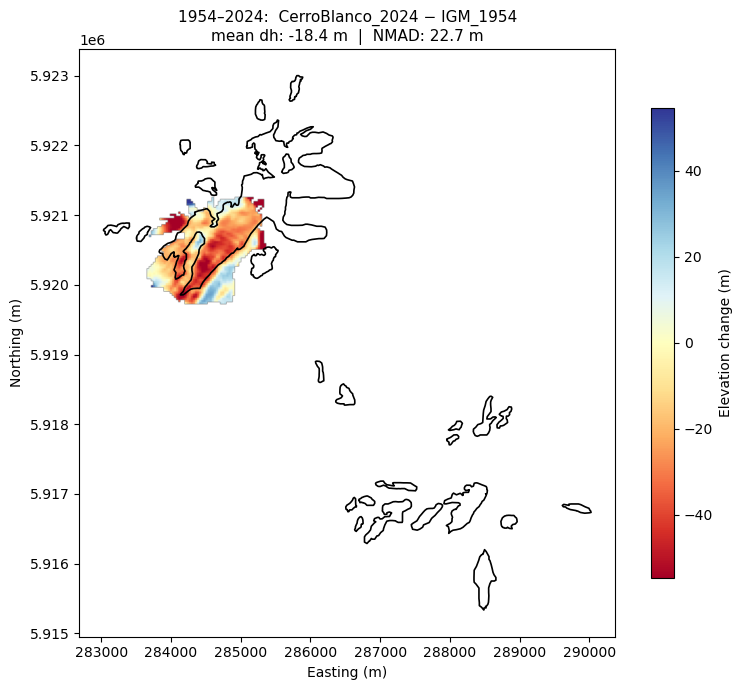

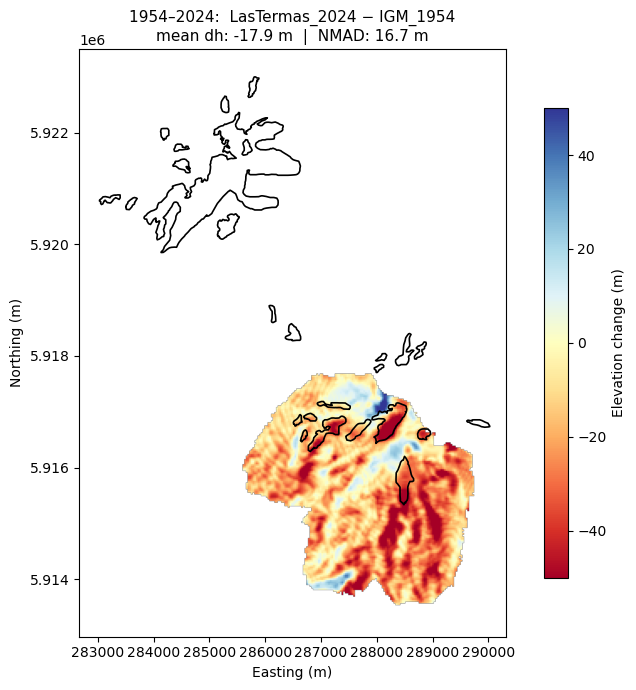

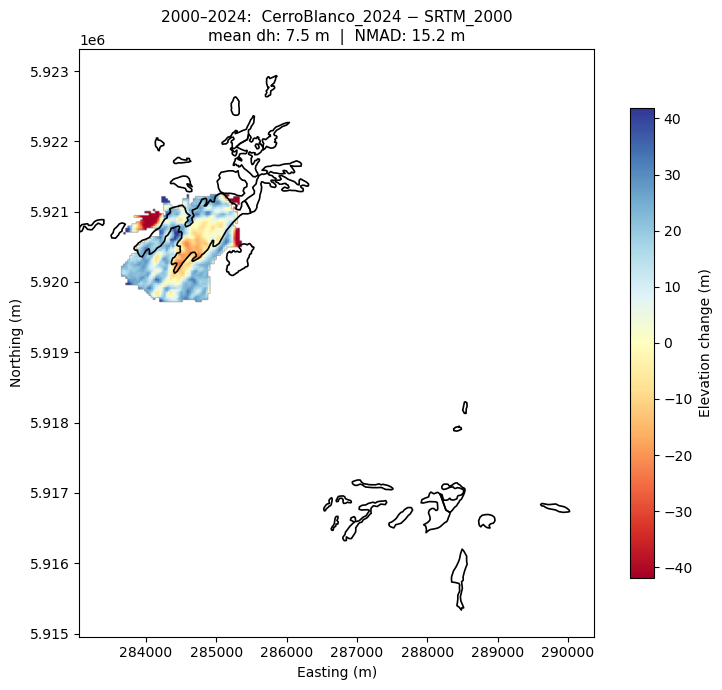

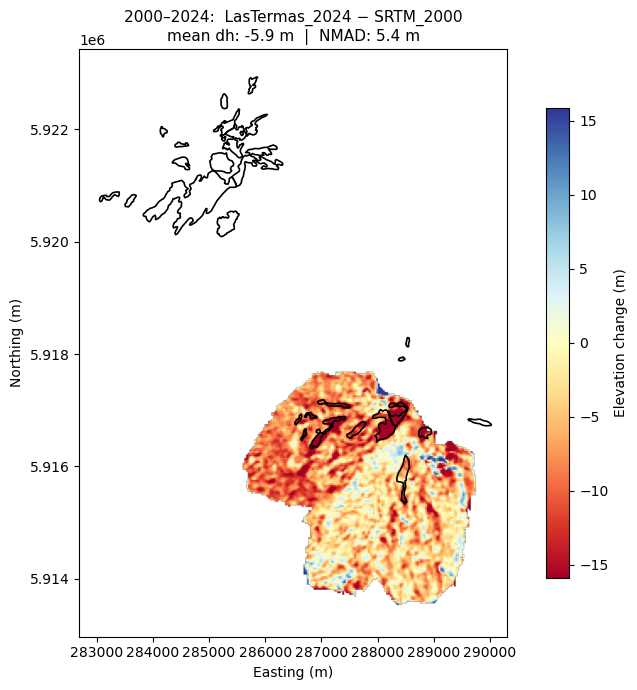

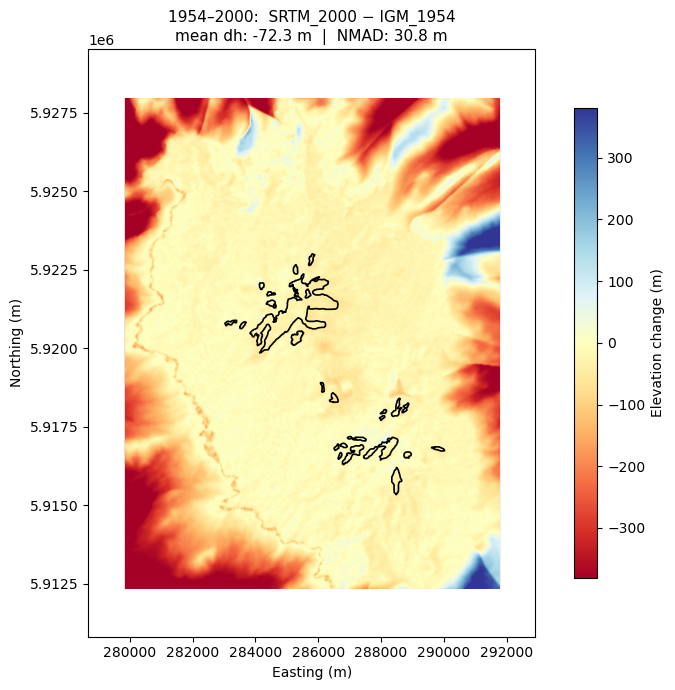

dh maps saved to figures/


In [5]:
# Step 5: dh maps with glacier outlines

print('Generating dh maps...')

for current_name, baseline_name, outline_label, t_start, t_end in EPOCHS:
    epoch_label = f'{current_name}_minus_{baseline_name}'
    dh_path = os.path.join(output_folder, f'{epoch_label}_dh.tif')
    if not os.path.exists(dh_path):
        continue

    with rasterio.open(dh_path) as src:
        data      = src.read(1).astype(float)
        transform = src.transform
        bounds    = src.bounds
        crs       = src.crs

    data[data > 1e10] = np.nan
    data[data < -1e4] = np.nan

    # Crop display to valid data extent
    valid_rows, valid_cols = np.where(np.isfinite(data))
    if len(valid_rows) == 0:
        print(f'  {epoch_label}: no valid data, skipping.')
        continue

    r0, r1 = valid_rows.min(), valid_rows.max()
    c0, c1 = valid_cols.min(), valid_cols.max()

    # Add 10% padding
    pad_r = max(int((r1 - r0) * 0.10), 20)
    pad_c = max(int((c1 - c0) * 0.10), 20)
    r0 = max(r0 - pad_r, 0)
    r1 = min(r1 + pad_r, data.shape[0])
    c0 = max(c0 - pad_c, 0)
    c1 = min(c1 + pad_c, data.shape[1])

    # Compute extent of cropped region in map coordinates
    left   = bounds.left + c0 * transform.a
    right  = bounds.left + c1 * transform.a
    top    = bounds.top  + r0 * transform.e
    bottom = bounds.top  + r1 * transform.e
    crop_extent = [left, right, bottom, top]

    data_crop = data[r0:r1, c0:c1]
    finite     = data_crop[np.isfinite(data_crop)]
    clim       = float(np.nanpercentile(np.abs(finite), 95)) if len(finite) > 0 else 10.0

    outlines = load_outlines(outline_label, crs)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(data_crop, cmap='RdYlBu', vmin=-clim, vmax=clim,
                   extent=crop_extent, origin='upper')
    outlines.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
    fig.colorbar(im, ax=ax, label='Elevation change (m)', shrink=0.8)
    ax.set_title(f'{t_start}–{t_end}:  {current_name} − {baseline_name}\n'
                 f'mean dh: {np.nanmean(finite):.1f} m  |  NMAD: {float(nmad(finite)):.1f} m',
                 fontsize=11)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    fig.tight_layout()
    fig.savefig(os.path.join(figures_folder, f'dh_map_{epoch_label}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('dh maps saved to figures/')

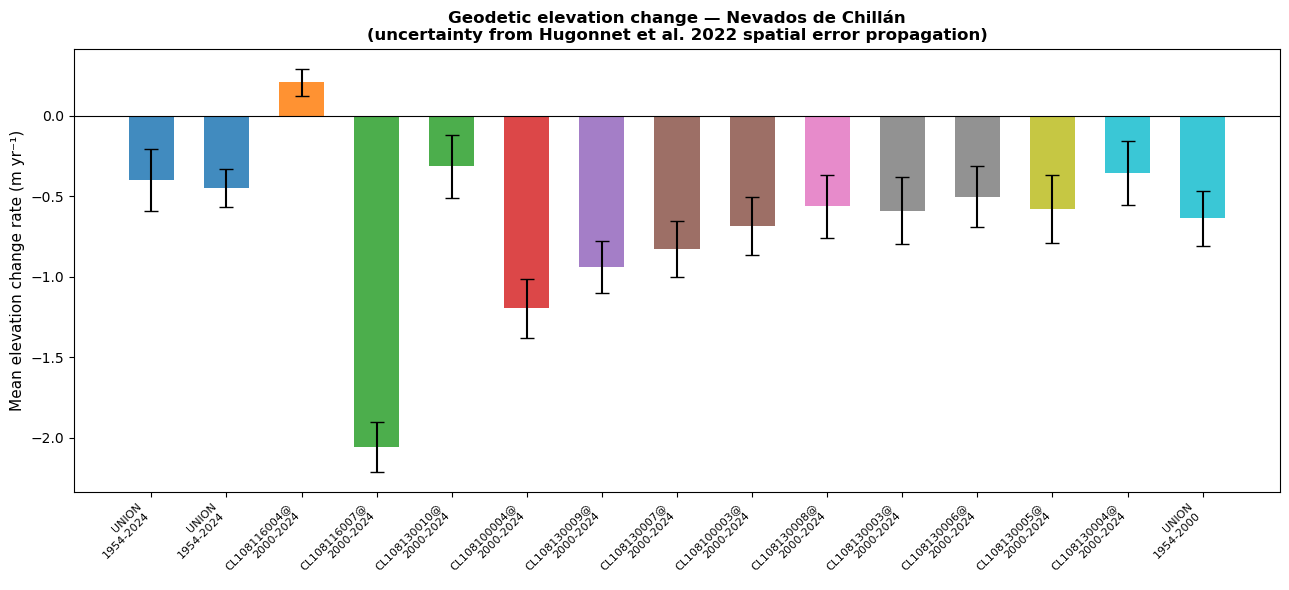


Notebook 3 complete.
  Results:  results/
  Figures:  figures/
  dh maps:  differenced_dems/


In [6]:
# Step 6: Bar charts of elevation change results
# (preserved from original notebook 3, updated with propagated uncertainties)

plt.rcParams.update({'font.family': 'sans-serif'})

if len(results_df) > 0:
    glaciers = results_df['glacier_id'].unique()
    epochs   = results_df['epoch'].unique()

    fig, ax = plt.subplots(figsize=(13, 6))
    x     = np.arange(len(results_df))
    width = 0.6

    colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
    bars = ax.bar(x, results_df['mean_dh_yr_m'], width,
                  yerr=results_df['sigma_dh_yr_m'],
                  capsize=5, color=colors, alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    labels = [f"{r['glacier_id']}\n{r['t_start']}-{r['t_end']}" 
              for _, r in results_df.iterrows()]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean elevation change rate (m yr⁻¹)', fontsize=11)
    ax.set_title('Geodetic elevation change — Nevados de Chillán\n'
                 '(uncertainty from Hugonnet et al. 2022 spatial error propagation)',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(figures_folder, 'elevation_change_summary.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

print('\nNotebook 3 complete.')
print(f'  Results:  {results_folder}/')
print(f'  Figures:  {figures_folder}/')
print(f'  dh maps:  {output_folder}/')

IGM_1954 (baseline): min=2174.9, max=3207.1, mean=2692.9, valid pixels=11,368
SRTM_2000: min=2165.6, max=3189.4, mean=2674.5, valid pixels=11,368
CerroBlanco_2024: min=2497.2, max=3233.5, mean=2825.1, valid pixels=1,916


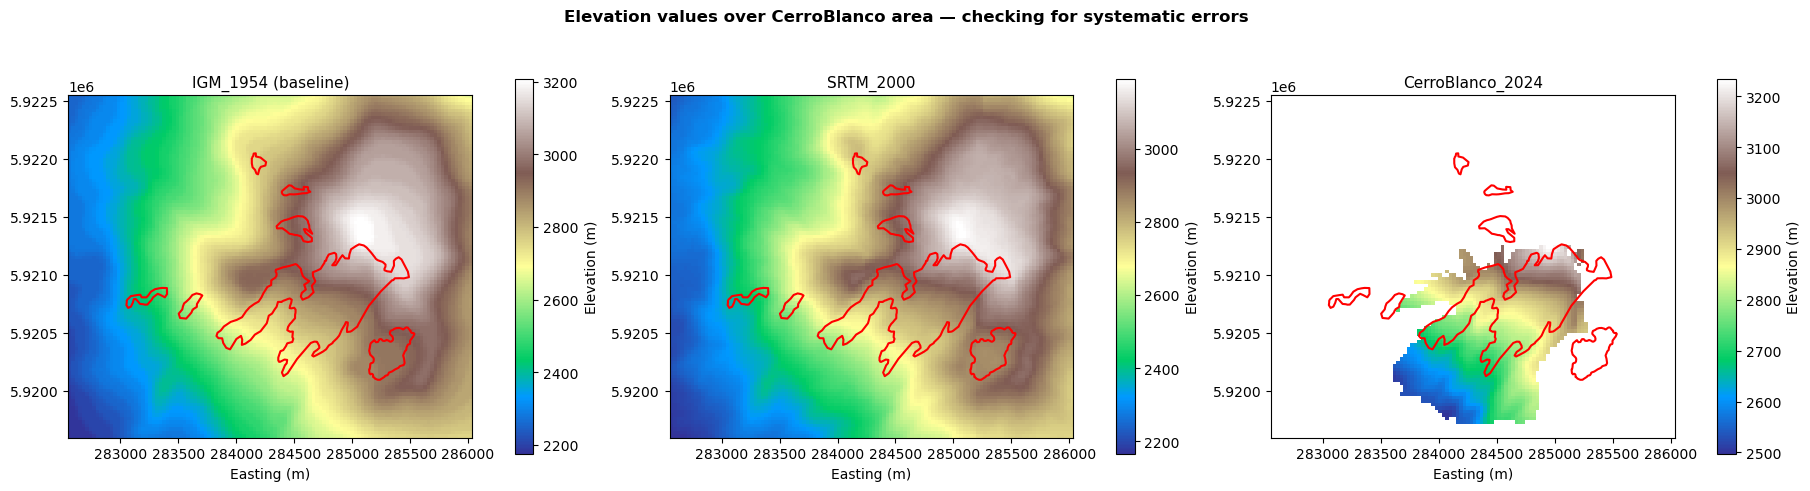

In [7]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Check each DEM's actual elevation values over the CerroBlanco area
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

dems_to_check = {
    'IGM_1954 (baseline)':    'coreg_dems/IGM_1954_coreg.tif',
    'SRTM_2000':              'coreg_dems/SRTM_2000_coreg.tif',
    'CerroBlanco_2024':       'coreg_dems/CerroBlanco_2024_coreg.tif',
}

# Load CerroBlanco outline for reference
cb_outline = gpd.read_file('example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp')
# filter to just CerroBlanco subcomplex
cb_outline = cb_outline[cb_outline['COD_GLA'].str.contains('CL108116', na=False)]

for ax, (name, path) in zip(axes, dems_to_check.items()):
    if not os.path.exists(path):
        path = path.replace('coreg_dems', 'aligned_dems').replace('_coreg', '_aligned')
    
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
        crs    = src.crs

    data[data > 1e10] = np.nan
    data[data < -1000] = np.nan

    # Crop to CerroBlanco area
    cb_reproj = cb_outline.to_crs(crs)
    xmin, ymin, xmax, ymax = cb_reproj.total_bounds
    pad = 500  # 500m padding
    
    with rasterio.open(path) as src:
        from rasterio.windows import from_bounds
        window = from_bounds(xmin-pad, ymin-pad, xmax+pad, ymax+pad, src.transform)
        data_crop = src.read(1, window=window).astype(float)
        crop_transform = src.window_transform(window)
        crop_extent = [
            xmin-pad, xmax+pad, ymin-pad, ymax+pad
        ]

    data_crop[data_crop > 1e10]  = np.nan
    data_crop[data_crop < -1000] = np.nan

    print(f'{name}: min={np.nanmin(data_crop):.1f}, max={np.nanmax(data_crop):.1f}, '
          f'mean={np.nanmean(data_crop):.1f}, valid pixels={np.sum(np.isfinite(data_crop)):,}')

    im = ax.imshow(data_crop, cmap='terrain', extent=crop_extent, origin='upper')
    cb_reproj.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5)
    fig.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Easting (m)')

plt.suptitle('Elevation values over CerroBlanco area — checking for systematic errors',
             fontsize=12, fontweight='bold')
plt.show()

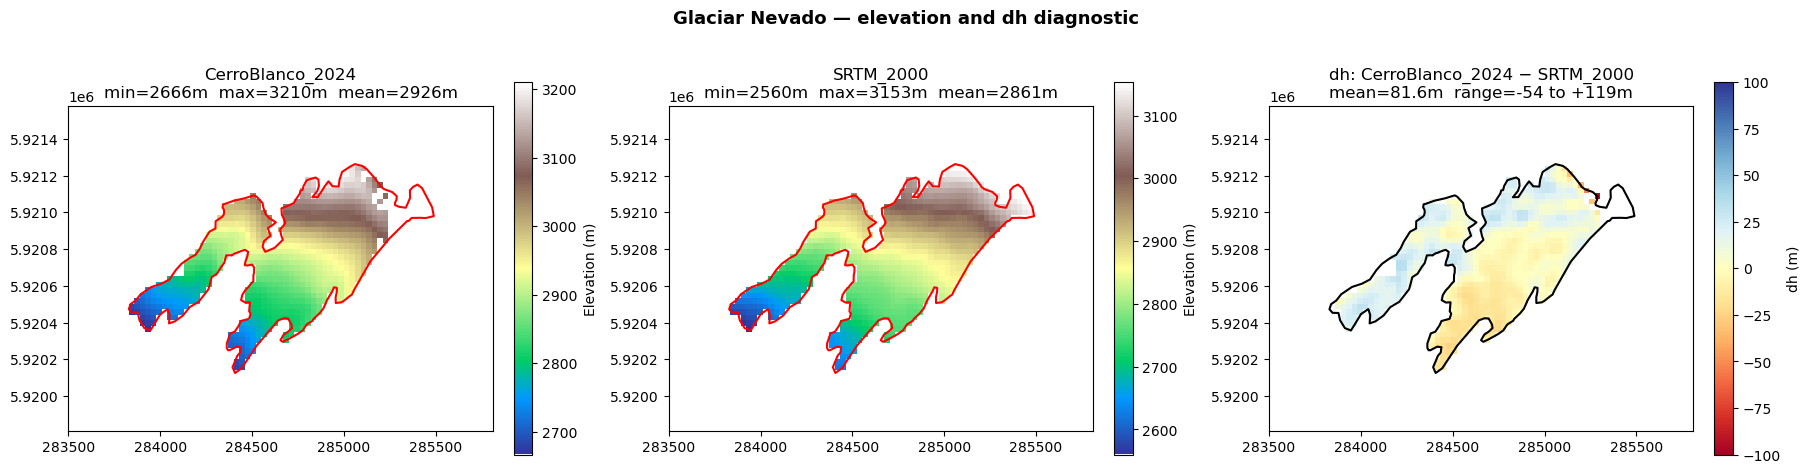

In [8]:
import rasterio
from rasterio.mask import mask as rio_mask
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

nevado_2019 = gdf_2019[gdf_2019['COD_GLA'] == 'CL108116004@'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Plot each DEM over Glaciar Nevado
for ax, (name, path) in zip(axes[:2], [
    ('CerroBlanco_2024', 'coreg_dems/CerroBlanco_2024_coreg.tif'),
    ('SRTM_2000',        'aligned_dems/SRTM_2000_aligned.tif'),
]):
    with rasterio.open(path) as src:
        nevado_reproj = nevado_2019.to_crs(src.crs)
        geoms = [g.__geo_interface__ for g in nevado_reproj.geometry]
        out, transform = rio_mask(src, geoms, crop=True, nodata=np.nan, pad=True, pad_width=10)
        data = out[0].astype(float)
        data[data > 1e10] = np.nan
        data[data < -1000] = np.nan
        bounds = rasterio.transform.array_bounds(data.shape[0], data.shape[1], transform)
        extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

    im = ax.imshow(data, cmap='terrain', extent=extent, origin='upper')
    nevado_reproj.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1.5)
    fig.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
    ax.set_title(f'{name}\nmin={np.nanmin(data):.0f}m  max={np.nanmax(data):.0f}m  mean={np.nanmean(data):.0f}m')

# Plot dh
ax = axes[2]
with rasterio.open('differenced_dems/CerroBlanco_2024_minus_SRTM_2000_dh.tif') as src:
    nevado_reproj = nevado_2019.to_crs(src.crs)
    geoms = [g.__geo_interface__ for g in nevado_reproj.geometry]
    out, transform = rio_mask(src, geoms, crop=True, nodata=np.nan, pad=True, pad_width=10)
    data = out[0].astype(float)
    data[data > 1e10] = np.nan
    data[data < -1e4] = np.nan
    bounds = rasterio.transform.array_bounds(data.shape[0], data.shape[1], transform)
    extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

im = ax.imshow(data, cmap='RdYlBu', vmin=-100, vmax=100, extent=extent, origin='upper')
nevado_reproj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)
fig.colorbar(im, ax=ax, label='dh (m)', shrink=0.8)
ax.set_title(f'dh: CerroBlanco_2024 − SRTM_2000\nmean={81.63:.1f}m  range=-54 to +119m')

plt.suptitle('Glaciar Nevado — elevation and dh diagnostic', fontsize=13, fontweight='bold')
plt.show()

In [9]:
with rasterio.open('aligned_dems/LasTermas_2024_aligned.tif') as src:
    nevado_reproj = nevado_2019.to_crs(src.crs)
    geoms = [g.__geo_interface__ for g in nevado_reproj.geometry]
    out, _ = rio_mask(src, geoms, crop=True, nodata=np.nan, pad=False)
    data = out[0].astype(float)
    data[data > 1e10] = np.nan
    data[data < -1000] = np.nan
    print(f"LasTermas ALIGNED (pre-coreg): mean={np.nanmean(data):.1f}m")

with rasterio.open('coreg_dems/LasTermas_2024_coreg.tif') as src:
    nevado_reproj = nevado_2019.to_crs(src.crs)
    geoms = [g.__geo_interface__ for g in nevado_reproj.geometry]
    out, _ = rio_mask(src, geoms, crop=True, nodata=np.nan, pad=False)
    data = out[0].astype(float)
    data[data > 1e10] = np.nan
    data[data < -1000] = np.nan
    print(f"LasTermas COREG (post-coreg):  mean={np.nanmean(data):.1f}m")

LasTermas ALIGNED (pre-coreg): mean=nanm
LasTermas COREG (post-coreg):  mean=nanm


In [10]:
# Check what dh values look like spatially for SRTM-IGM epoch
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

with rasterio.open('differenced_dems/SRTM_2000_minus_IGM_1954_dh.tif') as src:
    data = src.read(1).astype(float)
    data[data > 1e10] = np.nan
    data[data < -1e4] = np.nan
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    crs = src.crs

print(f'SRTM-IGM dh stats (full raster):')
print(f'  Valid pixels: {np.sum(np.isfinite(data)):,}')
print(f'  Mean: {np.nanmean(data):.2f}m')
print(f'  Median: {np.nanmedian(data):.2f}m')
print(f'  NMAD: {float(nmad(data[np.isfinite(data)])):.2f}m')

# Check just within union glacier mask
union_gdf = gpd.read_file('coreg_dems_xdem/glacier_union_mask.shp').to_crs(crs)
from rasterio.mask import mask as rio_mask
geoms = [g.__geo_interface__ for g in union_gdf.geometry]
out, _ = rio_mask(
    rasterio.open('differenced_dems/SRTM_2000_minus_IGM_1954_dh.tif'),
    geoms, crop=True, nodata=np.nan
)
dh_glacier = out[0].astype(float)
dh_glacier[dh_glacier > 1e10] = np.nan
dh_glacier[dh_glacier < -1e4] = np.nan

print(f'\nSRTM-IGM dh stats (within glacier union mask):')
print(f'  Valid pixels: {np.sum(np.isfinite(dh_glacier)):,}')
print(f'  Mean: {np.nanmean(dh_glacier):.2f}m')
print(f'  Median: {np.nanmedian(dh_glacier):.2f}m')

# Also check IGM coverage
with rasterio.open('coreg_dems_xdem/IGM_1954_coreg.tif') as src:
    igm = src.read(1).astype(float)
    igm[igm > 1e10] = np.nan
    igm[igm < -1000] = np.nan
    print(f'\nIGM 1954 valid pixels: {np.sum(np.isfinite(igm)):,} out of {igm.size:,}')
    print(f'IGM coverage: {np.sum(np.isfinite(igm))/igm.size*100:.1f}% of full grid')

SRTM-IGM dh stats (full raster):
  Valid pixels: 207,358
  Mean: -72.33m
  Median: -22.32m
  NMAD: 30.79m

SRTM-IGM dh stats (within glacier union mask):
  Valid pixels: 3,693
  Mean: -29.28m
  Median: -29.78m

IGM 1954 valid pixels: 207,358 out of 11,654,436
IGM coverage: 1.8% of full grid
